# Layered Liquidity + SMC + Kyle/OFI Backtest

This notebook follows the same style as `market_regime.ipynb` and `backtest_001.ipynb`:
- Load data
- Build indicators/features
- Generate strategy signals
- Run backtest
- Visualize indicator stack + trades + equity

Current strategy version: **Layer 1 (liquidity regime) + Layer 3 (Kyle/OFI execution)**.

In [1]:
# load lib
import warnings
warnings.filterwarnings('ignore')

import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add backend directory to path for importing app modules (same pattern as other notebooks)
backend_path = Path(__file__).parent.parent / "backend" if "__file__" in dir() else Path("../backend").resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

In [2]:
## Load datasource from deltalake and save it to local h5 file
# Prefer local HDF5 cache first for speed/reproducibility.

LOCAL_FILE = "stocks_data_latest.h5"
STORE_KEY = "stocks"


def load_stock_data_from_deltalake(remote_host: str = "https://minio.phuchuynh.xyz") -> pd.DataFrame:
    from deltalake import DeltaTable

    storage_options = {
        "AWS_ACCESS_KEY_ID": os.getenv("AWS_ACCESS_KEY_ID", ""),
        "AWS_SECRET_ACCESS_KEY": os.getenv("AWS_SECRET_ACCESS_KEY", ""),
        "AWS_ENDPOINT_URL": remote_host,
        "AWS_ALLOW_HTTP": "true",
        "AWS_EC2_METADATA_DISABLED": "true",
        "AWS_REGION": os.getenv("AWS_REGION", "us-east-1"),
        "aws_conditional_put": "etag",
    }

    dt = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)

    watchlist_path = "../backend/models/watchlist.csv"
    watchlist_symbols = pd.read_csv(watchlist_path).iloc[:, 0].astype(str).tolist()

    now = pd.Timestamp.now()
    start_date = now - pd.DateOffset(years=10)
    raw = dt.to_pandas(
        filters=[("date", ">=", start_date), ("symbol", "in", watchlist_symbols)],
        columns=["symbol", "date", "open", "high", "low", "close", "volume"],
    )

    # Critical: remove duplicate bars before unstacking/backtest
    raw = raw.drop_duplicates(subset=["date", "symbol"], keep="last")
    raw = raw.set_index(["date", "symbol"]).sort_index()
    stocks = raw.unstack(level=1).bfill().ffill()
    return stocks


if os.path.exists(LOCAL_FILE):
    print(f"Loading stock data from local HDF5 file: {LOCAL_FILE}")
    with pd.HDFStore(LOCAL_FILE, mode="r") as store:
        df = store[STORE_KEY]
else:
    print("Local HDF5 file not found, loading stock data from Delta Lake...")
    df = load_stock_data_from_deltalake()
    with pd.HDFStore(LOCAL_FILE, mode="w") as store:
        store.put(STORE_KEY, df)
    print(f"Stock data saved to {LOCAL_FILE}")

# Filter df to keep only columns for symbols in the watchlist (same structure as existing notebooks)
watchlist_path = "../backend/models/watchlist.csv"
watchlist_symbols = pd.read_csv(watchlist_path).iloc[:, 0].astype(str).tolist()
df = df.loc[:, df.columns.get_level_values('symbol').isin(watchlist_symbols)]

print(df.shape)
df.head()

Loading stock data from local HDF5 file: stocks_data_latest.h5
(2498, 990)


close                                                                                                                                                              \
symbol           AAA       ABB       ACB        ACV       ADS        AGG       AGR        ANV        APH       ASM       BAF       BCG        BCM       BFC       BID        BMP   
date                                                                                                                                                                               
2016-01-29  6.892738  8.201591  3.635365  20.629999  3.940815  15.284813  2.744280  17.299999  30.166281  8.001494  9.207305  9.230034  22.865768  9.290239  8.530189  32.146393   
2016-02-01  7.196829  8.201591  3.616231  20.629999  3.940815  15.284813  2.744280  17.299999  30.166281  7.954974  9.207305  9.230034  22.865768  9.217088  8.276314  31.615046   
2016-02-02  7.298193  8.201591  3.635365  20.629999  3.940815  15.284813  2.561327  17.299999  30.166281  7.861933  9.207305  9.277368  22.865768  9.107361  8.225538  31.349373   
2016-02-03  7.196829  8.201591  3.635365  20.629999  3.940815  15.284813  2.652804  17.299999  30.166281  7.861933  9.207305  9.230034  22.865768  9.363391  8.327088  32.412064   
2016-02-04  7.247511  8.201591  3.635365  20.629999  3.940815  15.284813  2.561327  17.299999  30.166281  7.954974  9.207305  9.324701  22.865768  9.692573  8.225538  32.412064   

                                                                                                                                                                               \
symbol       BSI   BSR        BVB        BVH       BVS        BWE       C4G       CEO    CII       CMG        CNG       CSV        CTD   CTG        CTI       CTR   CTS   DBC   
date                                                                                                                                                                            
2016-01-29  4.33  17.9  12.122261  41.869366  8.298028  12.096288  6.156264  6.550362  13.55  4.842000  13.514974  7.325260  60.330002  7.30  12.369515  9.927656  2.44  4.94   
2016-02-01  4.09  17.9  12.122261  41.048397  8.441097  12.096288  6.156264  6.594621  13.55  4.842000  13.769973  7.362256  60.330002  7.26  12.301176  9.927656  2.40  4.97   
2016-02-02  4.24  17.9  12.122261  40.884205  8.226494  12.096288  6.156264  6.461843  13.55  4.773803  13.599974  7.362256  59.889999  7.26  12.301176  9.927656  2.37  4.87   
2016-02-03  4.28  17.9  12.122261  40.473721  8.298028  12.096288  6.156264  6.506103  13.55  4.807901  13.822924  7.362256  59.450001  7.23  12.711215  9.927656  2.37  4.87   
2016-02-04  4.38  17.9  12.122261  40.802105  8.298028  12.096288  6.156264  6.461843  13.55  4.807901  14.179645  7.362256  61.650002  7.30  12.779555  9.927656  2.37  5.04   

                                                                                                                                                                               \
symbol           DCM        DDV   DGC       DGW       DHC       DIG   DPG   DPM       DPR        DRC       DRI       DTD        DVM       DXG    DXS       EIB   ELC      EVF   
date                                                                                                                                                                            
2016-01-29  6.780173   8.169215  8.76  4.202240  7.738285  3.868161  2.65  7.07  6.788446  17.342186  4.827948  6.003053  16.692913  6.330653  18.09  6.818066  8.93  5.72383   
2016-02-01  6.780173   8.513183  8.61  4.268942  7.790219  3.963671  2.65  7.10  6.597522  17.775740  4.827948  6.003053  16.692913  6.260701  18.09  6.688199  8.81  5.72383   
2016-02-02  6.780173   9.631075  8.69  4.268942  7.868122  3.963671  2.65  7.07  6.597522  17.689030  4.827948  6.003053  16.692913  6.260701  18.09  6.818066  8.89  5.72383   
2016-02-03  6.833560  10.061034  8.71  4.268942  7.712317  3.915916  2.65  7.20  7.000586  17.5

In [3]:
# Build single-symbol OHLCV frame for strategy development
SYMBOL = "DGW"  # change to any symbol in watchlist

# df columns are MultiIndex: (field, symbol)
symbol_df = df.xs(SYMBOL, axis=1, level='symbol').copy()
symbol_df = symbol_df[["open", "high", "low", "close", "volume"]].dropna().copy()
symbol_df.index = pd.to_datetime(symbol_df.index)
symbol_df = symbol_df[~symbol_df.index.duplicated(keep='last')].sort_index()

print(SYMBOL, symbol_df.shape)
symbol_df.tail()

DGW (2498, 5)


,open,high,low,close,volume
date,,,,,
2026-01-21,47.000000,47.000000,45.450001,45.849998,1191000.0
2026-01-22,46.200001,47.000000,44.799999,45.000000,2820300.0
2026-01-23,45.000000,45.900002,44.549999,45.750000,763600.0
2026-01-26,45.900002,45.900002,43.450001,44.250000,2735400.0
2026-01-27,43.799999,45.500000,43.150002,45.200001,2075300.0


In [4]:
# =============================================================================
# Layer 1 / Layer 3 feature engineering (SMC removed)
# =============================================================================

def compute_regime(df_in: pd.DataFrame, lookback: int = 20) -> pd.DataFrame:
    """Layer 1: normalized Amihud liquidity regime."""
    out = df_in.copy()
    out['ret_abs'] = out['close'].pct_change().abs()
    out['dv'] = out['close'] * out['volume']
    out['amihud_raw'] = out['ret_abs'] / out['dv'].replace(0, np.nan)
    out['amihud_roll'] = out['amihud_raw'].rolling(lookback).median()
    out['amihud_norm'] = out['amihud_raw'] / out['amihud_roll']

    def classify(x):
        if pd.isna(x):
            return 'insufficient_data'
        if x < 0.7:
            return 'deep'
        if x <= 1.5:
            return 'normal'
        if x <= 3.0:
            return 'thin'
        return 'illiquid'

    out['regime'] = out['amihud_norm'].apply(classify)
    return out


def compute_atr_series(df_in: pd.DataFrame, period: int = 14) -> pd.Series:
    high, low, close = df_in['high'], df_in['low'], df_in['close']
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low - close.shift(1)).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(period).mean()


def kyle_lambda_from_window(w: pd.DataFrame) -> float:
    d = w.copy()
    d['ret'] = d['close'].pct_change()
    d['dv'] = d['close'] * d['volume']
    d['sign'] = np.where(d['close'] > d['open'], 1.0, -1.0)
    d['ofi'] = d['sign'] * d['dv']
    d = d[['ret', 'ofi']].dropna()
    if len(d) < 5 or d['ofi'].var() == 0:
        return np.nan
    cov = np.cov(d['ret'].values, d['ofi'].values)
    if cov.shape == (2, 2) and cov[1, 1] != 0:
        return cov[0, 1] / cov[1, 1]
    return np.nan


def compute_kyle_ofi_features(df_in: pd.DataFrame, lookback: int = 20) -> pd.DataFrame:
    """Layer 3: build sub-signals and combined kyle_score."""
    out = df_in.copy()
    out['signed_flow'] = np.where(out['close'] > out['open'], 1.0, -1.0) * out['volume']

    absorption_flags = []
    persistent_flags = []
    lambda_drop_flags = []
    direction = []

    for i in range(len(out)):
        w = out.iloc[max(0, i - lookback): i + 1].copy()

        if len(w) < 12:
            absorption_flags.append(False)
            persistent_flags.append(False)
            lambda_drop_flags.append(False)
            direction.append('long')
            continue

        vol_trend = w['volume'].iloc[-5:].mean() / max(w['volume'].iloc[-10:-5].mean(), 1e-9)
        price_range = (w['high'] - w['low']).iloc[-5:].mean()
        avg_range = (w['high'] - w['low']).rolling(20).mean().iloc[-1]
        absorption = (vol_trend > 1.15) and np.isfinite(avg_range) and (price_range < avg_range * 0.75)

        ofi_series = w['signed_flow'].iloc[-10:]
        autocorr = ofi_series.autocorr(lag=1) if len(ofi_series) > 5 else 0.0
        persistent = bool(np.isfinite(autocorr) and autocorr > 0.35)

        half = max(lookback // 2, 5)
        early = w.iloc[:half]
        late = w.iloc[-half:]
        lam_early = kyle_lambda_from_window(early)
        lam_late = kyle_lambda_from_window(late)
        lambda_drop = (
            np.isfinite(lam_early)
            and np.isfinite(lam_late)
            and (lam_late < lam_early * 0.6)
        )

        absorption_flags.append(absorption)
        persistent_flags.append(persistent)
        lambda_drop_flags.append(lambda_drop)
        direction.append('long' if w['signed_flow'].iloc[-5:].sum() > 0 else 'short')

    out['absorption'] = absorption_flags
    out['persistent_flow'] = persistent_flags
    out['lambda_drop'] = lambda_drop_flags
    out['kyle_score'] = out[['absorption', 'persistent_flow', 'lambda_drop']].sum(axis=1).astype(int)
    out['direction'] = direction
    return out


def build_feature_frame(df_in: pd.DataFrame) -> pd.DataFrame:
    out = compute_regime(df_in, lookback=20)
    out = compute_kyle_ofi_features(out, lookback=20)
    out['atr14'] = compute_atr_series(out, period=14)

    # Master gate (SMC removed)
    out['regime_ok'] = out['regime'].isin(['deep', 'normal'])
    out['kyle_ok'] = out['kyle_score'] >= 2
    out['signal_ok'] = out['regime_ok'] & out['kyle_ok']

    # Position size score without SMC
    regime_quality = np.where(out['regime'] == 'deep', 1.0, np.where(out['regime'] == 'normal', 0.5, 0.0))
    kyle_quality = out['kyle_score'] / 3.0
    out['size_pct'] = np.minimum((regime_quality + kyle_quality) / 2.0, 1.0)

    return out


feat = build_feature_frame(symbol_df)
feat[['close', 'amihud_norm', 'regime', 'kyle_score', 'signal_ok', 'size_pct']].tail(20)

,close,amihud_norm,regime,kyle_score,signal_ok,size_pct
date,,,,,,
2025-12-29,40.099998,1.866546,thin,0,False,0.000000
2025-12-30,39.599998,1.736018,thin,0,False,0.000000
2025-12-31,39.000000,1.462504,normal,0,False,0.250000
2026-01-05,41.700001,1.255218,normal,0,False,0.250000
2026-01-06,42.200001,0.622369,deep,0,False,0.500000
2026-01-07,42.950001,0.604611,deep,0,False,0.500000
2026-01-08,41.200001,1.314596,normal,0,False,0.250000
2026-01-09,42.000000,0.766534,normal,0,False,0.250000
2026-01-12,43.700001,1.007417,normal,0,False,0.250000


In [ ]:
# =============================================================================
# Backtest engine with layered entry + rule-based exits
# =============================================================================

def run_backtest(feature_df: pd.DataFrame, atr_mult_stop: float = 1.8, rr_target: float = 2.5, initial_cash: float = 1_000_000.0):
    d = feature_df.copy()

    trades = []
    in_pos = False
    pos = None

    equity = []
    cash = initial_cash
    units = 0.0

    for i in range(len(d)):
        row = d.iloc[i]
        date = d.index[i]
        close = float(row['close'])

        # Mark-to-market equity
        mtm = cash + (units * close if in_pos else 0.0)
        equity.append(mtm)

        if not in_pos:
            if bool(row['signal_ok']) and np.isfinite(row['atr14']) and row['size_pct'] > 0:
                direction = row['direction']
                atr = float(row['atr14'])
                size_pct = float(row['size_pct'])
                risk_capital = cash * size_pct

                if direction == 'long':
                    stop = close - atr * atr_mult_stop
                    target = close + atr * atr_mult_stop * rr_target
                    units = risk_capital / close
                    cash -= units * close
                else:
                    # simple short accounting proxy
                    stop = close + atr * atr_mult_stop
                    target = close - atr * atr_mult_stop * rr_target
                    units = -(risk_capital / close)
                    cash -= units * close

                pos = {
                    'entry_date': date,
                    'direction': direction,
                    'entry': close,
                    'stop': float(stop),
                    'target': float(target),
                    'size_pct': size_pct,
                }
                in_pos = True
            continue

        # Exit logic when in position
        exit_reason = None
        days_held = (date - pos['entry_date']).days

        if pos['direction'] == 'long' and close <= pos['stop']:
            exit_reason = 'stop_hit'
        elif pos['direction'] == 'short' and close >= pos['stop']:
            exit_reason = 'stop_hit'
        elif pos['direction'] == 'long' and close >= pos['target']:
            exit_reason = 'target_hit'
        elif pos['direction'] == 'short' and close <= pos['target']:
            exit_reason = 'target_hit'
        elif row['amihud_norm'] > 3.0:
            exit_reason = 'regime_exit'
        elif days_held > 3 and row['amihud_norm'] > 2.0:
            # lambda warning -> tighten stop to breakeven
            pos['stop'] = pos['entry']

        if exit_reason is not None:
            cash += units * close
            pnl = (close - pos['entry']) * units
            ret_pct = pnl / max(abs(pos['entry'] * units), 1e-9)

            trades.append({
                'entry_date': pos['entry_date'],
                'exit_date': date,
                'direction': pos['direction'],
                'entry': pos['entry'],
                'exit': close,
                'stop': pos['stop'],
                'target': pos['target'],
                'size_pct': pos['size_pct'],
                'pnl': pnl,
                'ret_pct': ret_pct,
                'days_held': days_held,
                'exit_reason': exit_reason,
            })

            in_pos = False
            pos = None
            units = 0.0

    equity_curve = pd.Series(equity, index=d.index, name='equity')
    trades_df = pd.DataFrame(trades)
    return trades_df, equity_curve


trades_df, equity_curve = run_backtest(feat)
print(f"Trades: {len(trades_df)}")
trades_df.tail(10)

Trades: 23


,entry_date,exit_date,direction,entry,exit,stop,target,size_pct,pnl,ret_pct,days_held,exit_reason
13,2021-10-13,2021-11-16,short,47.069027,51.862709,49.681349,40.538222,0.583333,-78442.704735,-0.101844,34,stop_hit
14,2022-08-11,2022-08-15,short,47.269901,52.522110,50.043391,40.336177,0.833333,-114994.931951,-0.111111,4,stop_hit
15,2022-09-06,2022-09-07,long,55.523376,52.597141,52.757926,62.437003,0.583333,-34646.164543,-0.052703,1,stop_hit
16,2023-01-19,2023-02-02,long,32.413647,30.387793,30.854062,36.312609,0.833333,-56890.906911,-0.062500,14,stop_hit
17,2023-04-05,2023-06-12,long,24.535330,30.762951,22.798885,28.876443,0.833333,219009.527823,0.253823,68,target_hit
18,2023-07-20,2023-07-21,short,38.566235,41.192341,40.600127,33.481505,0.583333,-49827.143919,-0.068093,1,stop_hit
19,2024-01-02,2024-01-03,short,39.898830,42.645214,41.386454,36.179772,0.833333,-69097.335761,-0.068834,1,stop_hit
20,2024-05-16,2024-05-29,short,47.146229,48.519421,47.146229,41.342859,0.833333,-27560.667307,-0.029126,13,stop_hit
21,2024-07-09,2024-07-23,long,49.816322,47.298805,49.816322,54.087109,0.833333,-46658.961915,-0.050536,14,stop_hit
22,2025-06-12,2025-06-26,long,40.299999,46.000000,38.216071,45.509819,0.833333,125088.768223,0.141439,14,target_hit


In [6]:
# Performance summary

def summarize_performance(trades: pd.DataFrame, equity: pd.Series) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame([{
            'trades': 0,
            'win_rate': np.nan,
            'avg_ret_pct': np.nan,
            'median_ret_pct': np.nan,
            'profit_factor': np.nan,
            'total_pnl': 0.0,
            'max_drawdown_pct': np.nan,
            'equity_final': float(equity.iloc[-1]),
        }])

    wins = trades[trades['pnl'] > 0]
    losses = trades[trades['pnl'] < 0]
    gross_profit = wins['pnl'].sum()
    gross_loss = abs(losses['pnl'].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    dd = equity / equity.cummax() - 1.0

    return pd.DataFrame([{
        'trades': int(len(trades)),
        'win_rate': float((trades['pnl'] > 0).mean()),
        'avg_ret_pct': float(trades['ret_pct'].mean()),
        'median_ret_pct': float(trades['ret_pct'].median()),
        'profit_factor': float(profit_factor) if np.isfinite(profit_factor) else np.nan,
        'total_pnl': float(trades['pnl'].sum()),
        'max_drawdown_pct': float(dd.min()),
        'equity_final': float(equity.iloc[-1]),
    }])


summary = summarize_performance(trades_df, equity_curve)
summary.T

,0
trades,2.300000e+01
win_rate,4.782609e-01
avg_ret_pct,1.220947e-02
median_ret_pct,-2.912623e-02
profit_factor,1.284079e+00
total_pnl,1.863681e+05
max_drawdown_pct,-2.739236e-01
equity_final,1.186368e+06


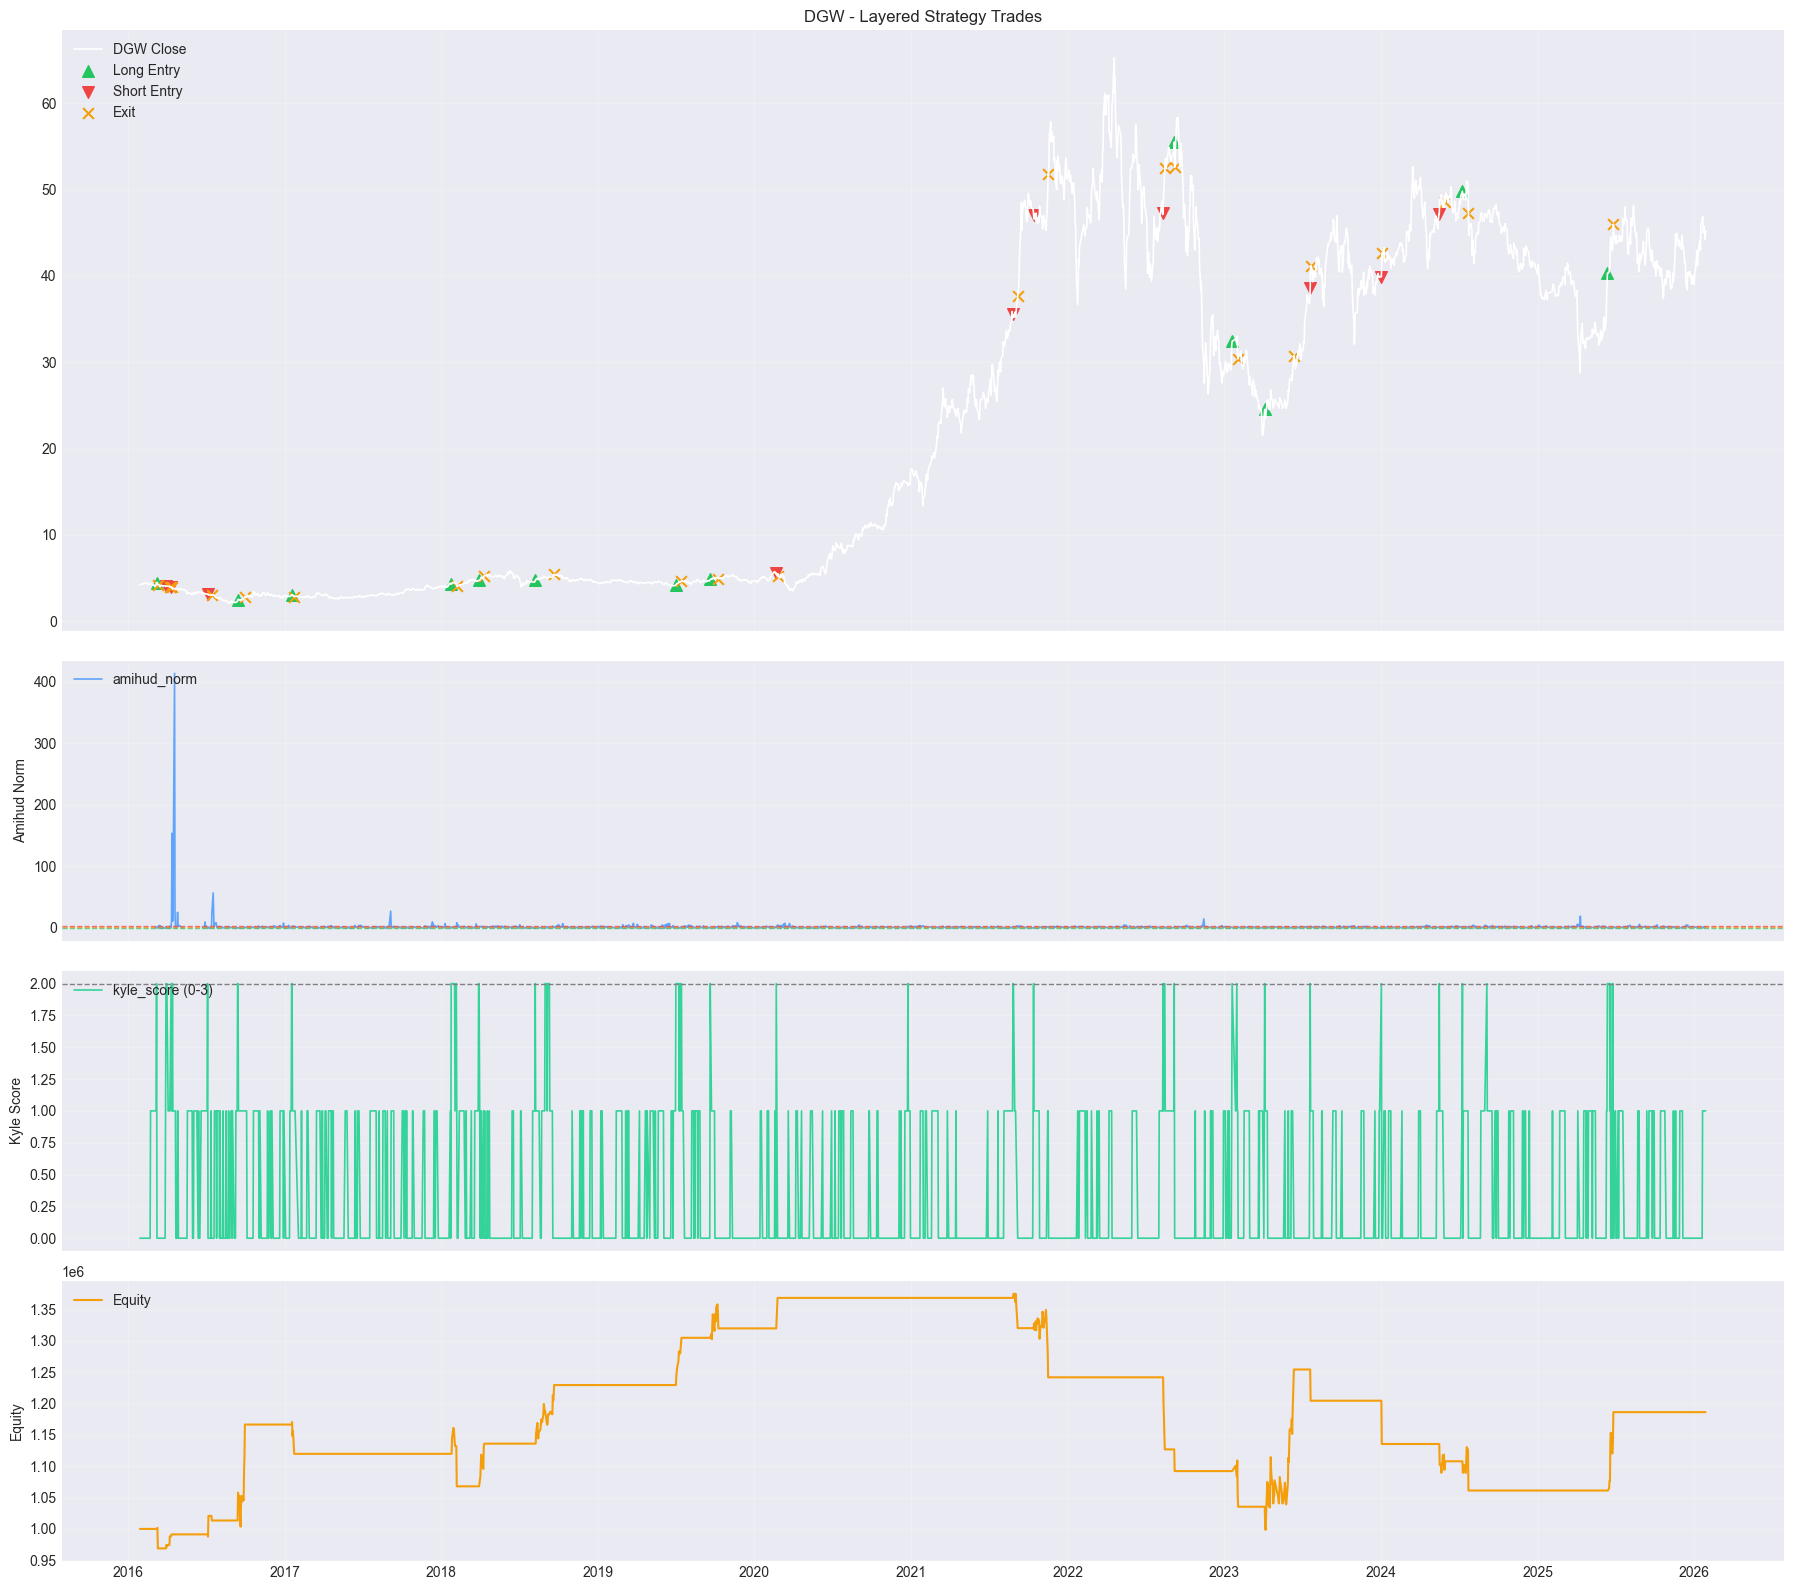

In [7]:
# =============================================================================
# Visualization: price + layer indicators + trades + equity
# =============================================================================

plot_df = feat.copy()
plot_df['equity'] = equity_curve.reindex(plot_df.index)

fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=True, gridspec_kw={'height_ratios': [3, 1.4, 1.4, 1.4]})

# --- Panel 1: Price + entries/exits ---
axes[0].plot(plot_df.index, plot_df['close'], color='white', lw=1.2, label=f'{SYMBOL} Close')

if not trades_df.empty:
    long_trades = trades_df[trades_df['direction'] == 'long']
    short_trades = trades_df[trades_df['direction'] == 'short']

    axes[0].scatter(long_trades['entry_date'], long_trades['entry'], marker='^', color='#22c55e', s=70, label='Long Entry')
    axes[0].scatter(short_trades['entry_date'], short_trades['entry'], marker='v', color='#ef4444', s=70, label='Short Entry')
    axes[0].scatter(trades_df['exit_date'], trades_df['exit'], marker='x', color='#f59e0b', s=60, label='Exit')

axes[0].set_title(f'{SYMBOL} - Layered Strategy Trades')
axes[0].legend(loc='upper left')

# --- Panel 2: Layer 1 (Amihud normalized + thresholds) ---
axes[1].plot(plot_df.index, plot_df['amihud_norm'], color='#60a5fa', lw=1.2, label='amihud_norm')
axes[1].axhline(0.7, color='#22c55e', ls='--', lw=1, alpha=0.7)
axes[1].axhline(1.5, color='#f59e0b', ls='--', lw=1, alpha=0.7)
axes[1].axhline(3.0, color='#ef4444', ls='--', lw=1, alpha=0.7)
axes[1].set_ylabel('Amihud Norm')
axes[1].legend(loc='upper left')

# --- Panel 3: Layer 3 score ---
axes[2].plot(plot_df.index, plot_df['kyle_score'], color='#34d399', lw=1.2, label='kyle_score (0-3)')
axes[2].axhline(2.0, color='gray', ls='--', lw=1)
axes[2].set_ylabel('Kyle Score')
axes[2].legend(loc='upper left')

# --- Panel 4: Equity curve ---
axes[3].plot(plot_df.index, plot_df['equity'], color='#f59e0b', lw=1.5, label='Equity')
axes[3].set_ylabel('Equity')
axes[3].legend(loc='upper left')

for ax in axes:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [8]:
# Optional: inspect last signals and trade decisions
cols = [
    'close', 'regime', 'amihud_norm',
    'kyle_score', 'signal_ok', 'direction', 'size_pct', 'atr14'
]
feat[cols].tail(30)

,close,regime,amihud_norm,kyle_score,signal_ok,direction,size_pct,atr14
date,,,,,,,,
2025-12-15,38.400002,thin,2.787824,0,False,short,0.000000,1.696429
2025-12-16,40.299999,illiquid,5.070828,0,False,short,0.000000,1.682143
2025-12-17,39.950001,thin,2.805456,0,False,short,0.000000,1.621428
2025-12-18,40.450001,normal,1.238019,0,False,short,0.250000,1.632143
2025-12-19,40.150002,normal,0.700963,0,False,long,0.250000,1.582143
2025-12-22,40.500000,normal,1.101739,0,False,long,0.250000,1.564286
2025-12-23,39.799999,normal,1.421224,0,False,long,0.250000,1.496429
2025-12-24,40.000000,deep,0.471678,0,False,long,0.500000,1.403572
2025-12-25,39.599998,normal,0.978336,0,False,long,0.250000,1.417857
